# Backtest: 5 Estrategias de Salida · Strong Momentum

Misma entrada (11_Strong_Momentum, rolling P75/P25 N=500).
5 variantes de salida para reducir drawdown.

### Mecánica de salida anticipada en Polymarket
Cuando vendes antes de resolución, vendes tus shares al **bid** actual:

```
PnL_exit = STAKE × (bid_actual / ask_entrada − 1)
```

Si el bid ha subido respecto a tu ask de entrada → ganas.
Si ha bajado → pierdes, pero menos que perder todo el STAKE.

### Estrategias de salida

| # | Nombre | Lógica |
|---|--------|--------|
| 0 | **Hold (baseline)** | Sin salida — esperar a resolución |
| 1 | **Stop-Loss Bid** | Salir si el bid cae por debajo del X% del ask de entrada |
| 2 | **Momentum Reversal** | Salir si btc_return_since_open cruza cero en contra |
| 3 | **Time Stop** | Si queda <20% del mercado y el bid < ask entrada → salir |
| 4 | **Trailing Stop** | Tracking del bid máximo, salir si cae X% desde el pico |
| 5 | **Threshold Cross-Back** | Salir si btc_return vuelve al rango normal (< P50) |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})

CFG = dict(
    DATA_PATH    = '../dataset_with_resolution.csv',
    STAKE        = 10.0,
    INIT_CAPITAL = 100.0,
    ENTRY_LO     = 0.10,
    ENTRY_HI     = 0.60,
    TRAIN_FRAC   = 0.40,
    VAL_FRAC     = 0.15,
    PERCENTILE   = 75,
    ROLLING_WINDOW = 500,
)

print("Configuración:")
for k, v in CFG.items():
    print(f"  {k:<18} = {v}")

Configuración:
  DATA_PATH          = ../dataset_with_resolution.csv
  STAKE              = 10.0
  INIT_CAPITAL       = 100.0
  ENTRY_LO           = 0.1
  ENTRY_HI           = 0.6
  TRAIN_FRAC         = 0.4
  VAL_FRAC           = 0.15
  PERCENTILE         = 75
  ROLLING_WINDOW     = 500


---
## 1 · Carga y Preparación

In [2]:
# ═══ Carga ════════════════════════════════════════════════════════════
df = pd.read_csv(CFG['DATA_PATH'], parse_dates=['timestamp'])
if df['timestamp'].dt.tz is None:
    df['timestamp'] = df['timestamp'].dt.tz_localize('UTC')
else:
    df['timestamp'] = df['timestamp'].dt.tz_convert('UTC')
df = df.sort_values(['timestamp', 'market_slug']).reset_index(drop=True)

res_check = df.groupby('market_slug')['resolution'].nunique()
bad = res_check[res_check > 1].index
if len(bad):
    df = df[~df['market_slug'].isin(bad)]

num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
df['market_progress'] = df['market_progress'].clip(0.0, 1.0)
df['y'] = (df['resolution'].str.lower() == 'up').astype(int)

# Features
df['vol_ratio'] = df['volatility_3m'] / (df['volatility_5m'] + 1e-9)

# Split
market_order = df.groupby('market_slug')['timestamp'].min().sort_values().index.tolist()
N = len(market_order)
n_train = int(N * CFG['TRAIN_FRAC'])
n_val   = int(N * CFG['VAL_FRAC'])
train_m = market_order[:n_train]
test_m  = market_order[n_train + n_val:]

tr = df[df['market_slug'].isin(train_m)].copy()
te = df[df['market_slug'].isin(test_m)].copy()

# Umbrales fijos de seed
tr_w = tr[(tr['market_progress'] >= CFG['ENTRY_LO']) & (tr['market_progress'] <= CFG['ENTRY_HI'])]
SEED_UP   = tr_w['btc_return_since_open'].quantile(CFG['PERCENTILE'] / 100)
SEED_DOWN = tr_w['btc_return_since_open'].quantile(1 - CFG['PERCENTILE'] / 100)

print(f"Dataset: {len(df):,} filas, {df['market_slug'].nunique()} mercados")
print(f"Train: {len(train_m)} | Test: {len(test_m)} mercados")
print(f"Seed thresholds: UP={SEED_UP:+.6f}  DOWN={SEED_DOWN:+.6f}")

Dataset: 171,267 filas, 1783 mercados
Train: 713 | Test: 803 mercados
Seed thresholds: UP=+0.000314  DOWN=-0.000356


---
## 2 · Motor de Backtest con Salida

In [3]:
# ═══════════════════════════════════════════════════════════════════════
# ROLLING CALIBRATOR (idéntico al signal_engine)
# ═══════════════════════════════════════════════════════════════════════
class RollingCalibrator:
    def __init__(self, window_size, percentile, seed_up, seed_down):
        self.buffer = deque(maxlen=window_size)
        self.percentile = percentile
        self.threshold_up = seed_up
        self.threshold_down = seed_down
        self.min_samples = 50

    def feed(self, values):
        for v in values:
            if not np.isnan(v):
                self.buffer.append(v)
        if len(self.buffer) >= self.min_samples:
            arr = np.array(self.buffer)
            self.threshold_up = float(np.percentile(arr, self.percentile))
            self.threshold_down = float(np.percentile(arr, 100 - self.percentile))


# ═══════════════════════════════════════════════════════════════════════
# FUNCIONES DE SALIDA
# ═══════════════════════════════════════════════════════════════════════
# Cada exit_fn recibe:
#   snap        = snapshot actual (fila del df)
#   direction   = 'UP' o 'DOWN'
#   entry_ask   = precio de entrada
#   entry_ret   = btc_return_since_open en el momento de entrada
#   best_bid    = mejor bid visto desde la entrada (para trailing)
#   params      = dict con parámetros de la estrategia de salida
# Retorna: True si hay que salir, False si no


def exit_hold(snap, direction, entry_ask, entry_ret, best_bid, params):
    """Baseline: nunca salir, esperar resolución."""
    return False


def exit_stoploss_bid(snap, direction, entry_ask, entry_ret, best_bid, params):
    """
    Stop-Loss por Bid: salir si el bid cae por debajo de un % del ask de entrada.
    Ejemplo: stop=0.80 → salir si bid < 0.80 × entry_ask
    """
    bid_col = 'up_bid_p_1' if direction == 'UP' else 'down_bid_p_1'
    bid = snap.get(bid_col, np.nan)
    if pd.isna(bid) or bid <= 0:
        return False
    return bid < entry_ask * params['stop_pct']


def exit_momentum_reversal(snap, direction, entry_ask, entry_ret, best_bid, params):
    """
    Momentum Reversal: salir si btc_return_since_open cruza cero en contra.
    Si entramos UP con ret>0, salir si ret cae por debajo de -margin.
    Si entramos DOWN con ret<0, salir si ret sube por encima de +margin.
    """
    ret = snap.get('btc_return_since_open', np.nan)
    if pd.isna(ret):
        return False
    margin = params.get('margin', 0.0)
    if direction == 'UP' and ret < -margin:
        return True
    if direction == 'DOWN' and ret > margin:
        return True
    return False


def exit_time_stop(snap, direction, entry_ask, entry_ret, best_bid, params):
    """
    Time Stop: si el mercado está en el último X% de su vida Y
    el bid está por debajo del ask de entrada → salir.
    Evita quedarte atrapado cuando ya es tarde para recuperar.
    """
    prog = snap.get('market_progress', np.nan)
    if pd.isna(prog):
        return False
    if prog < params['time_limit']:
        return False
    bid_col = 'up_bid_p_1' if direction == 'UP' else 'down_bid_p_1'
    bid = snap.get(bid_col, np.nan)
    if pd.isna(bid) or bid <= 0:
        return False
    return bid < entry_ask


def exit_trailing_stop(snap, direction, entry_ask, entry_ret, best_bid, params):
    """
    Trailing Stop: rastrear el mejor bid visto desde la entrada.
    Salir si el bid actual cae un X% desde ese máximo.
    """
    bid_col = 'up_bid_p_1' if direction == 'UP' else 'down_bid_p_1'
    bid = snap.get(bid_col, np.nan)
    if pd.isna(bid) or bid <= 0 or best_bid <= 0:
        return False
    drop_from_peak = (best_bid - bid) / best_bid
    return drop_from_peak > params['trail_pct']


def exit_threshold_crossback(snap, direction, entry_ask, entry_ret, best_bid, params):
    """
    Threshold Cross-Back: salir si btc_return vuelve a ser "normal"
    (cruza de vuelta hacia cero más allá de un ratio del umbral de entrada).
    Si entraste UP porque ret > threshold_up, salir si ret < threshold_up × ratio.
    """
    ret = snap.get('btc_return_since_open', np.nan)
    if pd.isna(ret):
        return False
    ratio = params['crossback_ratio']
    if direction == 'UP' and ret < entry_ret * ratio:
        return True
    if direction == 'DOWN' and ret > entry_ret * ratio:
        return True
    return False


# ═══════════════════════════════════════════════════════════════════════
# REGISTRO DE ESTRATEGIAS DE SALIDA
# ═══════════════════════════════════════════════════════════════════════
EXIT_STRATEGIES = [
    ('0_Hold',              exit_hold,                {}),
    ('1_StopLoss_80',       exit_stoploss_bid,        {'stop_pct': 0.80}),
    ('2_Mom_Reversal',      exit_momentum_reversal,   {'margin': 0.0001}),
    ('3_TimeStop_80',       exit_time_stop,           {'time_limit': 0.80}),
    ('4_Trailing_15',       exit_trailing_stop,       {'trail_pct': 0.15}),
    ('5_Crossback_30',      exit_threshold_crossback, {'crossback_ratio': 0.30}),
]

print(f"Estrategias de salida: {len(EXIT_STRATEGIES)}")
for name, fn, params in EXIT_STRATEGIES:
    print(f"  • {name}: {params if params else 'sin parámetros'}")

Estrategias de salida: 6
  • 0_Hold: sin parámetros
  • 1_StopLoss_80: {'stop_pct': 0.8}
  • 2_Mom_Reversal: {'margin': 0.0001}
  • 3_TimeStop_80: {'time_limit': 0.8}
  • 4_Trailing_15: {'trail_pct': 0.15}
  • 5_Crossback_30: {'crossback_ratio': 0.3}


In [4]:
# ═══════════════════════════════════════════════════════════════════════
# MOTOR DE BACKTEST CON SALIDA
# ═══════════════════════════════════════════════════════════════════════

def early_exit_pnl(stake, entry_ask, exit_bid):
    """PnL cuando vendes tus shares al bid antes de resolución."""
    return stake * (exit_bid / entry_ask - 1.0)


def run_backtest_with_exit(test_df, cfg, exit_fn, exit_params):
    """
    Backtest cronológico:
    - Entrada: Strong Momentum (rolling P75/P25, N=500)
    - Salida: exit_fn evalúa cada snapshot post-entrada
    - PnL exit anticipado: STAKE × (bid / ask_entry − 1)
    - PnL resolución: win_net o loss_net del dataset
    - 1 trade por mercado
    """
    STAKE = cfg['STAKE']
    lo, hi = cfg['ENTRY_LO'], cfg['ENTRY_HI']
    pct = cfg['PERCENTILE']
    rw = cfg['ROLLING_WINDOW']

    # Calibrador con pre-carga de train
    cal = RollingCalibrator(rw, pct, SEED_UP, SEED_DOWN)
    train_vals = tr_w['btc_return_since_open'].dropna().values
    seed_data = train_vals[-rw * 3:] if len(train_vals) > rw * 3 else train_vals
    cal.feed(seed_data)

    # Mercados de test en orden cronológico
    mkt_order = (
        test_df.groupby('market_slug')['timestamp'].min()
        .sort_values().index.tolist()
    )

    trades = []

    for mkt in mkt_order:
        snaps = test_df[test_df['market_slug'] == mkt].sort_values('timestamp')
        window = snaps[(snaps['market_progress'] >= lo) & (snaps['market_progress'] <= hi)]

        # Alimentar calibrador con este mercado (zona de operación)
        op_vals = window['btc_return_since_open'].values

        if window.empty:
            cal.feed(op_vals)
            continue

        t_up = cal.threshold_up
        t_down = cal.threshold_down

        # ── ENTRADA ──────────────────────────────────────────────────
        entry_row = None
        direction = None
        for idx_e, row in window.iterrows():
            ret = row.get('btc_return_since_open', np.nan)
            if pd.isna(ret):
                continue
            if ret > t_up:
                ask = row.get('up_ask_p_1', np.nan)
                if not pd.isna(ask) and 0 < ask < 1:
                    entry_row = row
                    direction = 'UP'
                    break
            elif ret < t_down:
                ask = row.get('down_ask_p_1', np.nan)
                if not pd.isna(ask) and 0 < ask < 1:
                    entry_row = row
                    direction = 'DOWN'
                    break

        # Actualizar calibrador DESPUÉS de decidir entrada
        cal.feed(op_vals)

        if entry_row is None:
            continue

        entry_ask = entry_row['up_ask_p_1'] if direction == 'UP' else entry_row['down_ask_p_1']
        entry_ts = entry_row['timestamp']
        entry_ret = entry_row['btc_return_since_open']

        # PnL a resolución (si no salimos antes)
        resolution = snaps['resolution'].iloc[0]
        actual_up = (resolution.lower() == 'up')
        won = (actual_up if direction == 'UP' else not actual_up)
        win_net = entry_row['up_win_net'] if direction == 'UP' else entry_row['down_win_net']
        loss_net = entry_row['up_loss_net'] if direction == 'UP' else entry_row['down_loss_net']
        pnl_at_resolution = win_net if won else loss_net

        # ── SALIDA: evaluar snapshots posteriores ────────────────────
        exit_type = 'RESOLUTION'
        exit_pnl = pnl_at_resolution
        exit_progress = snaps['market_progress'].iloc[-1]

        future = snaps[snaps['timestamp'] > entry_ts]
        bid_col = 'up_bid_p_1' if direction == 'UP' else 'down_bid_p_1'
        best_bid = entry_ask  # inicializar con el ask de entrada

        for _, snap in future.iterrows():
            cur_bid = snap.get(bid_col, np.nan)
            if not pd.isna(cur_bid) and cur_bid > 0:
                best_bid = max(best_bid, cur_bid)

            should_exit = exit_fn(
                snap, direction, entry_ask, entry_ret, best_bid, exit_params
            )
            if should_exit and not pd.isna(cur_bid) and cur_bid > 0:
                exit_type = 'EARLY_EXIT'
                exit_pnl = early_exit_pnl(STAKE, entry_ask, cur_bid)
                exit_progress = snap['market_progress']
                break

        trades.append({
            'timestamp': entry_ts,
            'market': mkt,
            'direction': direction,
            'resolution': resolution,
            'won_at_resolution': won,
            'entry_progress': entry_row['market_progress'],
            'entry_ask': entry_ask,
            'entry_ret': entry_ret,
            'exit_type': exit_type,
            'exit_progress': exit_progress,
            'pnl': exit_pnl,
            'pnl_at_resolution': pnl_at_resolution,
        })

    if not trades:
        return pd.DataFrame(), pd.Series(dtype=float)

    tdf = pd.DataFrame(trades).sort_values('timestamp').reset_index(drop=True)
    tdf['cumulative_pnl'] = tdf['pnl'].cumsum()
    tdf['equity'] = cfg['INIT_CAPITAL'] + tdf['cumulative_pnl']

    equity_s = pd.concat([
        pd.Series([cfg['INIT_CAPITAL']], index=[tdf['timestamp'].iloc[0]]),
        tdf.set_index('timestamp')['equity'],
    ])
    return tdf, equity_s


print("Motor de backtest con salida definido.")

Motor de backtest con salida definido.


---
## 3 · Ejecutar Backtests

In [5]:
# ═══════════════════════════════════════════════════════════════════════
# 3. EJECUTAR
# ═══════════════════════════════════════════════════════════════════════
all_results = {}
all_logs = {}
all_equity = {}

print(f"Backtesting {len(EXIT_STRATEGIES)} variantes sobre {len(test_m)} mercados...\n")
print(f"{'Exit':<22} {'N':>5} {'WR':>7} {'PnL(€)':>10} {'ROI':>8} {'Sharpe':>8} "
      f"{'MDD':>8} {'Exits':>6} {'Exit%':>6}")
print("═" * 95)

for name, exit_fn, params in EXIT_STRATEGIES:
    tdf, eq_s = run_backtest_with_exit(te, CFG, exit_fn, params)
    all_logs[name] = tdf
    all_equity[name] = eq_s

    if tdf.empty:
        all_results[name] = dict(n=0, wr=np.nan, pnl=0, roi=0, sharpe=0, mdd=0,
                                  n_exits=0, exit_pct=0)
        print(f"{name:<22} sin trades")
        continue

    n = len(tdf)
    wr = (tdf['pnl'] > 0).mean()  # WR basado en PnL, no en resolución
    pnl = tdf['pnl'].sum()
    roi = pnl / CFG['INIT_CAPITAL']
    pa = tdf['pnl'].values
    sharpe = pa.mean() / (pa.std() + 1e-9) * np.sqrt(n)
    eq = eq_s.values
    rm = np.maximum.accumulate(eq)
    mdd = ((eq - rm) / rm).min()
    n_exits = (tdf['exit_type'] == 'EARLY_EXIT').sum()
    exit_pct = n_exits / n

    all_results[name] = dict(n=n, wr=wr, pnl=pnl, roi=roi, sharpe=sharpe,
                              mdd=mdd, n_exits=n_exits, exit_pct=exit_pct)

    print(f"{name:<22} {n:>5} {wr:>6.1%} {pnl:>+10.2f} {roi:>+7.2%} "
          f"{sharpe:>8.3f} {mdd:>+7.2%} {n_exits:>6} {exit_pct:>5.0%}")

print("═" * 95)

Backtesting 6 variantes sobre 803 mercados...

Exit                       N      WR     PnL(€)      ROI   Sharpe      MDD  Exits  Exit%
═══════════════════════════════════════════════════════════════════════════════════════════════
0_Hold                   741  69.0%    +115.31 +115.31%    0.602 -83.87%      0    0%
1_StopLoss_80            741  37.5%     +70.61 +70.61%    0.675 -75.05%    463   62%
2_Mom_Reversal           741  52.6%    +362.62 +362.62%    2.782 -44.23%    350   47%
3_TimeStop_80            741  49.8%    +151.72 +151.72%    1.046 -89.05%    365   49%
4_Trailing_15            741  33.1%     -69.94 -69.94%   -1.074 -119.06%    613   83%
5_Crossback_30           741  40.1%    +264.29 +264.29%    2.593 -45.12%    467   63%
═══════════════════════════════════════════════════════════════════════════════════════════════


---
## 4 · Ranking por ROI

In [6]:
# ═══════════════════════════════════════════════════════════════════════
# 4. RANKING
# ═══════════════════════════════════════════════════════════════════════
ranking = pd.DataFrame(all_results).T.sort_values('roi', ascending=False)

print("RANKING POR ROI")
print("═" * 100)
print(f"{'Rk':>3} {'Exit':<22} {'N':>5} {'WR':>7} {'PnL(€)':>10} {'ROI':>8} "
      f"{'Sharpe':>8} {'MDD':>8} {'Exits':>6} {'Exit%':>6} {'ΔPnL vs Hold':>13}")
print("─" * 100)

hold_pnl = all_results.get('0_Hold', {}).get('pnl', 0)

for rank, (name, row) in enumerate(ranking.iterrows(), 1):
    if row['n'] == 0:
        continue
    delta = row['pnl'] - hold_pnl
    flag = ' ★' if row['roi'] > 0 and row['mdd'] > ranking.loc['0_Hold', 'mdd'] else ''
    print(f"{rank:>3} {name:<22} {int(row['n']):>5} {row['wr']:>6.1%} "
          f"{row['pnl']:>+10.2f} {row['roi']:>+7.2%} {row['sharpe']:>8.3f} "
          f"{row['mdd']:>+7.2%} {int(row['n_exits']):>6} {row['exit_pct']:>5.0%} "
          f"{delta:>+12.2f}{flag}")

print("\n★ = ROI > 0 y mejor drawdown que Hold")

RANKING POR ROI
════════════════════════════════════════════════════════════════════════════════════════════════════
 Rk Exit                       N      WR     PnL(€)      ROI   Sharpe      MDD  Exits  Exit%  ΔPnL vs Hold
────────────────────────────────────────────────────────────────────────────────────────────────────
  1 2_Mom_Reversal           741  52.6%    +362.62 +362.62%    2.782 -44.23%    350   47%      +247.31 ★
  2 5_Crossback_30           741  40.1%    +264.29 +264.29%    2.593 -45.12%    467   63%      +148.98 ★
  3 3_TimeStop_80            741  49.8%    +151.72 +151.72%    1.046 -89.05%    365   49%       +36.41
  4 0_Hold                   741  69.0%    +115.31 +115.31%    0.602 -83.87%      0    0%        +0.00
  5 1_StopLoss_80            741  37.5%     +70.61 +70.61%    0.675 -75.05%    463   62%       -44.70 ★
  6 4_Trailing_15            741  33.1%     -69.94 -69.94%   -1.074 -119.06%    613   83%      -185.25

★ = ROI > 0 y mejor drawdown que Hold


---
## 5 · Curvas de Equity

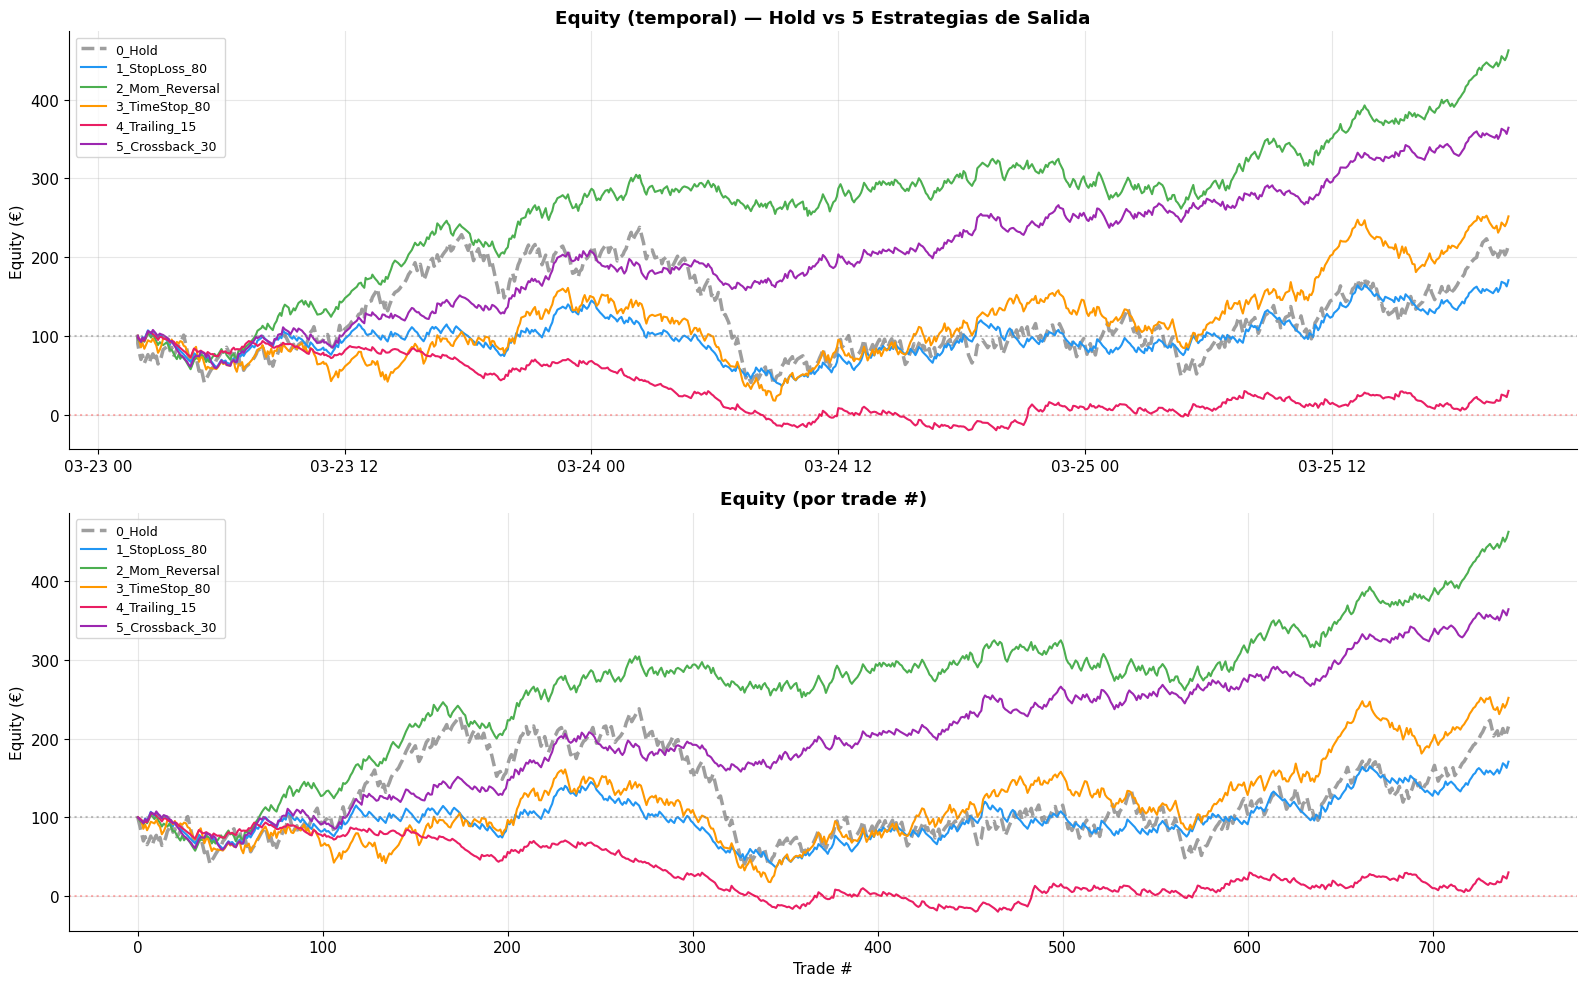

In [7]:
# ═══════════════════════════════════════════════════════════════════════
# 5. CURVAS DE EQUITY
# ═══════════════════════════════════════════════════════════════════════
COLORS = ['#9E9E9E', '#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Panel 1: Temporal
ax = axes[0]
for i, (name, _, _) in enumerate(EXIT_STRATEGIES):
    eq = all_equity[name]
    if len(eq) > 1:
        lw = 2.5 if name == '0_Hold' else 1.5
        ls = '--' if name == '0_Hold' else '-'
        ax.plot(eq.index, eq.values, label=name, color=COLORS[i], lw=lw, ls=ls)
ax.axhline(CFG['INIT_CAPITAL'], ls=':', color='gray', alpha=0.5)
ax.axhline(0, ls=':', color='red', alpha=0.3)
ax.set_title('Equity (temporal) — Hold vs 5 Estrategias de Salida', fontweight='bold')
ax.set_ylabel('Equity (€)')
ax.legend(fontsize=9)

# Panel 2: Por trade
ax = axes[1]
for i, (name, _, _) in enumerate(EXIT_STRATEGIES):
    eq = all_equity[name]
    if len(eq) > 1:
        lw = 2.5 if name == '0_Hold' else 1.5
        ls = '--' if name == '0_Hold' else '-'
        ax.plot(range(len(eq)), eq.values, label=name, color=COLORS[i], lw=lw, ls=ls)
ax.axhline(CFG['INIT_CAPITAL'], ls=':', color='gray', alpha=0.5)
ax.axhline(0, ls=':', color='red', alpha=0.3)
ax.set_title('Equity (por trade #)', fontweight='bold')
ax.set_ylabel('Equity (€)')
ax.set_xlabel('Trade #')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 6 · Análisis de Salidas: ¿Cuándo se activan?

In [8]:
# ═══════════════════════════════════════════════════════════════════════
# 6. ANÁLISIS DE SALIDAS
# ═══════════════════════════════════════════════════════════════════════
print("ANÁLISIS DE SALIDAS ANTICIPADAS")
print("═" * 95)

for name, _, _ in EXIT_STRATEGIES:
    if name == '0_Hold':
        continue
    tdf = all_logs[name]
    if tdf.empty:
        continue

    exits = tdf[tdf['exit_type'] == 'EARLY_EXIT']
    holds = tdf[tdf['exit_type'] == 'RESOLUTION']

    print(f"\n  ── {name} ──")
    print(f"    Total trades: {len(tdf)}")
    print(f"    Early exits:  {len(exits)} ({len(exits)/len(tdf):.0%})")
    print(f"    Hold to res:  {len(holds)} ({len(holds)/len(tdf):.0%})")

    if len(exits) > 0:
        # PnL de los exits
        print(f"\n    Exit anticipado:")
        print(f"      PnL total:     {exits['pnl'].sum():+.2f}€")
        print(f"      PnL medio:     {exits['pnl'].mean():+.4f}€")
        print(f"      % con PnL > 0: {(exits['pnl'] > 0).mean():.1%}")

        # ¿Cuántos exits evitaron una pérdida mayor?
        exits_copy = exits.copy()
        saved = exits_copy[exits_copy['pnl'] > exits_copy['pnl_at_resolution']]
        worse = exits_copy[exits_copy['pnl'] <= exits_copy['pnl_at_resolution']]
        print(f"\n      Exits que MEJORARON PnL (vs hold): {len(saved)}/{len(exits)} ({len(saved)/len(exits):.0%})")
        if len(saved) > 0:
            print(f"        PnL exit: {saved['pnl'].sum():+.2f}€  vs  PnL hold: {saved['pnl_at_resolution'].sum():+.2f}€  "
                  f"→ ahorro: {saved['pnl'].sum() - saved['pnl_at_resolution'].sum():+.2f}€")
        print(f"      Exits que EMPEORARON PnL (vs hold): {len(worse)}/{len(exits)} ({len(worse)/len(exits):.0%})")
        if len(worse) > 0:
            print(f"        PnL exit: {worse['pnl'].sum():+.2f}€  vs  PnL hold: {worse['pnl_at_resolution'].sum():+.2f}€  "
                  f"→ coste: {worse['pnl'].sum() - worse['pnl_at_resolution'].sum():+.2f}€")

    if len(holds) > 0:
        print(f"\n    Hold to resolution:")
        print(f"      PnL total: {holds['pnl'].sum():+.2f}€")
        print(f"      WR:        {(holds['pnl'] > 0).mean():.1%}")

ANÁLISIS DE SALIDAS ANTICIPADAS
═══════════════════════════════════════════════════════════════════════════════════════════════

  ── 1_StopLoss_80 ──
    Total trades: 741
    Early exits:  463 (62%)
    Hold to res:  278 (38%)

    Exit anticipado:
      PnL total:     -1230.75€
      PnL medio:     -2.6582€
      % con PnL > 0: 0.0%

      Exits que MEJORARON PnL (vs hold): 230/463 (50%)
        PnL exit: -638.68€  vs  PnL hold: -2302.30€  → ahorro: +1663.62€
      Exits que EMPEORARON PnL (vs hold): 233/463 (50%)
        PnL exit: -592.06€  vs  PnL hold: +1116.25€  → coste: -1708.31€

    Hold to resolution:
      PnL total: +1301.36€
      WR:        100.0%

  ── 2_Mom_Reversal ──
    Total trades: 741
    Early exits:  350 (47%)
    Hold to res:  391 (53%)

    Exit anticipado:
      PnL total:     -1299.61€
      PnL medio:     -3.7132€
      % con PnL > 0: 2.9%

      Exits que MEJORARON PnL (vs hold): 219/350 (63%)
        PnL exit: -868.91€  vs  PnL hold: -2192.19€  → ahorro:

---
## 7 · Drawdown Detallado

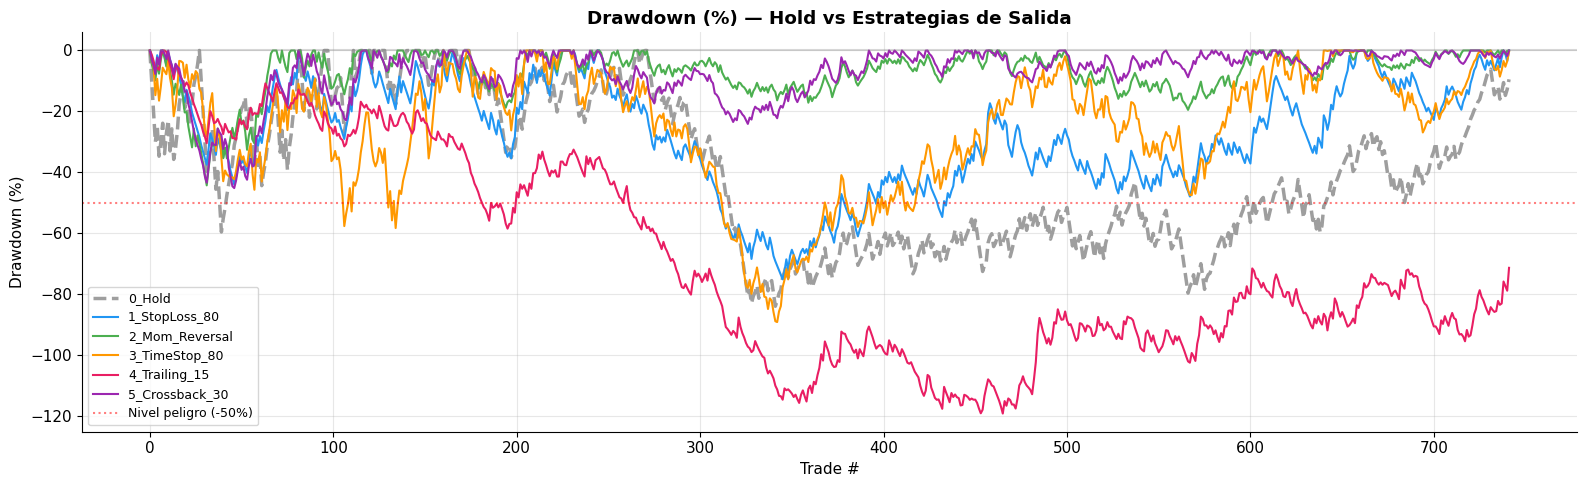


DRAWDOWN COMPARATIVO
══════════════════════════════════════════════════════════════════════
Exit                        MDD   Min Equity  Mejora DD
──────────────────────────────────────────────────────────────────────
0_Hold                  -83.9%       38.35€     +0.0%
1_StopLoss_80           -75.0%       36.14€     +8.8% ✅
2_Mom_Reversal          -44.2%       57.57€    +39.6% ✅
3_TimeStop_80           -89.1%       17.61€     -5.2%
4_Trailing_15          -119.1%      -19.94€    -35.2%
5_Crossback_30          -45.1%       58.98€    +38.8% ✅


In [9]:
# ═══════════════════════════════════════════════════════════════════════
# 7. DRAWDOWN
# ═══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(16, 5))

for i, (name, _, _) in enumerate(EXIT_STRATEGIES):
    eq = all_equity[name]
    if len(eq) < 2:
        continue
    eq_vals = eq.values
    rm = np.maximum.accumulate(eq_vals)
    dd = (eq_vals - rm) / rm * 100  # en %
    lw = 2.5 if name == '0_Hold' else 1.5
    ls = '--' if name == '0_Hold' else '-'
    ax.plot(range(len(dd)), dd, label=name, color=COLORS[i], lw=lw, ls=ls)

ax.axhline(0, ls='-', color='gray', alpha=0.3)
ax.axhline(-50, ls=':', color='red', alpha=0.5, label='Nivel peligro (-50%)')
ax.set_title('Drawdown (%) — Hold vs Estrategias de Salida', fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.set_xlabel('Trade #')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Tabla resumen de drawdown
print("\nDRAWDOWN COMPARATIVO")
print("═" * 70)
print(f"{'Exit':<22} {'MDD':>8} {'Min Equity':>12} {'Mejora DD':>10}")
print("─" * 70)

hold_mdd = all_results.get('0_Hold', {}).get('mdd', 0)
for name, _, _ in EXIT_STRATEGIES:
    r = all_results[name]
    if r['n'] == 0:
        continue
    eq = all_equity[name].values
    min_eq = eq.min()
    dd_improvement = r['mdd'] - hold_mdd  # positivo = mejor (menos negativo)
    flag = ' ✅' if dd_improvement > 0 else ''
    print(f"{name:<22} {r['mdd']:>+7.1%} {min_eq:>11.2f}€ {dd_improvement:>+9.1%}{flag}")

---
## 8 · Distribución de PnL por Tipo de Salida

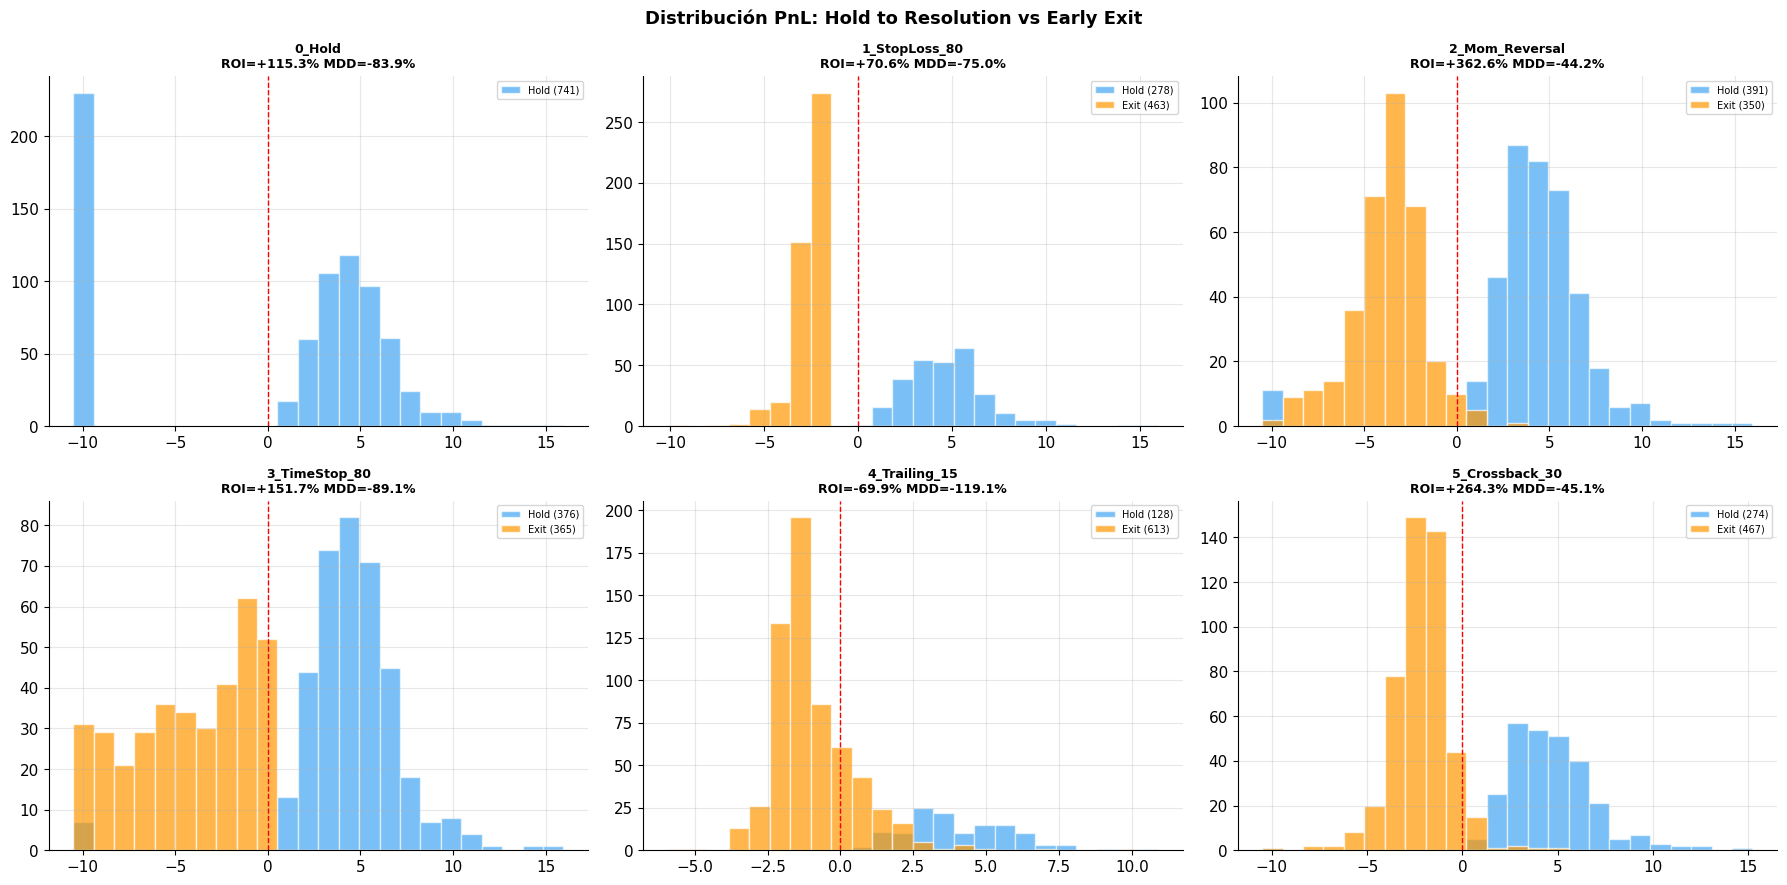

In [10]:
# ═══════════════════════════════════════════════════════════════════════
# 8. DISTRIBUCIÓN DE PnL
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes_f = axes.flatten()

for i, (name, _, _) in enumerate(EXIT_STRATEGIES):
    ax = axes_f[i]
    tdf = all_logs[name]
    if tdf.empty:
        continue

    exits = tdf[tdf['exit_type'] == 'EARLY_EXIT']['pnl'].values
    holds = tdf[tdf['exit_type'] == 'RESOLUTION']['pnl'].values

    bins = np.linspace(tdf['pnl'].min() - 0.5, tdf['pnl'].max() + 0.5, 25)

    if len(holds) > 0:
        ax.hist(holds, bins=bins, alpha=0.6, color='#2196F3', label=f'Hold ({len(holds)})', edgecolor='white')
    if len(exits) > 0:
        ax.hist(exits, bins=bins, alpha=0.7, color='#FF9800', label=f'Exit ({len(exits)})', edgecolor='white')

    ax.axvline(0, ls='--', color='red', lw=1)
    r = all_results[name]
    ax.set_title(f"{name}\nROI={r['roi']:+.1%} MDD={r['mdd']:+.1%}",
                 fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)

plt.suptitle('Distribución PnL: Hold to Resolution vs Early Exit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9 · Monte Carlo — Top 3

In [11]:
# ═══════════════════════════════════════════════════════════════════════
# 9. MONTE CARLO — TOP 3 POR ROI
# ═══════════════════════════════════════════════════════════════════════
N_MC = 30
TEST_PCT = 0.45
rng = np.random.RandomState(SEED)

all_markets = df['market_slug'].unique().tolist()
n_test_mc = int(len(all_markets) * TEST_PCT)

# Top 3
top3 = ranking.head(3).index.tolist()
top3_exits = {name: (fn, params) for name, fn, params in EXIT_STRATEGIES if name in top3}
# Incluir Hold siempre
if '0_Hold' not in top3:
    top3 = ['0_Hold'] + top3[:2]
    top3_exits['0_Hold'] = (exit_hold, {})

mc_all = {name: [] for name in top3}

print(f"Monte Carlo: {N_MC} iters, {n_test_mc} mercados/iter")
print(f"Evaluando: {top3}")

for it in range(N_MC):
    shuffled = rng.permutation(all_markets)
    mc_test = df[df['market_slug'].isin(shuffled[:n_test_mc])].copy()

    for name in top3:
        fn, params = top3_exits[name]
        tdf, eq_s = run_backtest_with_exit(mc_test, CFG, fn, params)
        if tdf.empty:
            mc_all[name].append(dict(n=0, pnl=0, roi=0, mdd=0, sharpe=0))
            continue
        pa = tdf['pnl'].values
        eq = eq_s.values
        rm = np.maximum.accumulate(eq)
        mc_all[name].append(dict(
            n=len(tdf), pnl=pa.sum(), roi=pa.sum()/CFG['INIT_CAPITAL'],
            mdd=((eq-rm)/rm).min(),
            sharpe=pa.mean()/(pa.std()+1e-9)*np.sqrt(len(tdf)),
        ))

print(f"\n{'═' * 80}")
print(f"  MONTE CARLO — RESUMEN")
print(f"{'═' * 80}")

for name in top3:
    mc_df = pd.DataFrame(mc_all[name])
    mc_v = mc_df[mc_df['n'] > 0]
    if mc_v.empty:
        continue
    print(f"\n  ── {name} ──")
    for col, label, fmt in [
        ('roi',    'ROI',    '+.2%'), ('pnl', 'PnL(€)', '+.2f'),
        ('sharpe', 'Sharpe', '.2f'),  ('mdd', 'MDD',    '.2%'),
    ]:
        v = mc_v[col].dropna()
        print(f"    {label:<10} media={v.mean():{fmt}}  "
              f"p10={v.quantile(0.10):{fmt}}  p90={v.quantile(0.90):{fmt}}")
    print(f"    %ROI>0:  {(mc_v['roi']>0).mean():.0%}")
    print(f"    %MDD>-50%: {(mc_v['mdd']>-0.50).mean():.0%}")

Monte Carlo: 30 iters, 802 mercados/iter
Evaluando: ['0_Hold', '2_Mom_Reversal', '5_Crossback_30']


KeyboardInterrupt: 

---
## 10 · Veredicto

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# 10. VEREDICTO
# ═══════════════════════════════════════════════════════════════════════
D = '═' * 70
print(D)
print('  VEREDICTO: ESTRATEGIAS DE SALIDA')
print(D)

hold = all_results['0_Hold']

print(f"\n  BASELINE (Hold to resolution):")
print(f"    ROI={hold['roi']:+.2%}  PnL={hold['pnl']:+.2f}€  MDD={hold['mdd']:.1%}  Sharpe={hold['sharpe']:.2f}")

print(f"\n  COMPARATIVA:")
print(f"  {'Exit':<22} {'ΔROI':>8} {'ΔMDD':>8} {'ΔPnL':>10} {'¿Mejora?':>10}")
print(f"  {'─' * 62}")

best_name = None
best_score = -999

for name, _, _ in EXIT_STRATEGIES:
    r = all_results[name]
    if r['n'] == 0 or name == '0_Hold':
        continue
    d_roi = r['roi'] - hold['roi']
    d_mdd = r['mdd'] - hold['mdd']  # positivo = mejor
    d_pnl = r['pnl'] - hold['pnl']

    # Score compuesto: queremos mejor ROI y mejor (menos negativo) MDD
    score = d_roi * 100 + d_mdd * 50  # ponderado
    if score > best_score:
        best_score = score
        best_name = name

    tag = '✅ SÍ' if d_roi > 0 or d_mdd > 0.05 else '❌ NO'
    print(f"  {name:<22} {d_roi:>+7.2%} {d_mdd:>+7.1%} {d_pnl:>+10.2f} {tag:>10}")

print(f"\n  RECOMENDACIÓN:")
if best_name:
    r = all_results[best_name]
    d_mdd = r['mdd'] - hold['mdd']
    print(f"    Mejor combinación: {best_name}")
    print(f"      ROI={r['roi']:+.2%}  MDD={r['mdd']:.1%} (mejora DD en {d_mdd:+.1%})")
    if r['roi'] < hold['roi'] and d_mdd > 0:
        print(f"    ℹ️  Sacrifica algo de ROI ({r['roi']-hold['roi']:+.2%}) a cambio de menos drawdown")

print(f"\n  ⚠️  CONSIDERACIONES PARA PRODUCCIÓN:")
print(f"     - La salida anticipada requiere monitorizar bid en cada snapshot")
print(f"     - Hay que poder enviar orden de venta a Polymarket vía API")
print(f"     - El bid real puede ser peor que el del snapshot (slippage)")
print(f"     - En mercados de 5min, la ventana para ejecutar el exit es corta")
print(f"     - Verificar que la API de Polymarket soporta sell de shares")
print(D)